# 🌋 Análisis Sísmico de Chile
**Proyecto de Portafolio**

Este notebook se conecta a la API de Boostr para descargar, limpiar y analizar visualmente los sismos más recientes del país.

In [6]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set_theme(style="darkgrid", palette="mako")
print("Librerías importadas correctamente.")

Librerías importadas correctamente.


### 1. Extracción de Datos vía API

### 2. Transformación y Limpieza con Pandas

In [7]:
import requests
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid", palette="mako")

# 1. Configurar la petición a la API del USGS
url = "https://earthquake.usgs.gov/fdsnws/event/1/query"

# Calculamos las fechas dinámicamente (hace 1 año exacto hasta hoy)
fecha_inicio = (datetime.now() - timedelta(days=365)).strftime('%Y-%m-%d')
fecha_fin = datetime.now().strftime('%Y-%m-%d')

print(f"Obteniendo sismos desde {fecha_inicio} hasta {fecha_fin}...")

# Parámetros (Bounding Box geográfico aproximado de Chile y magnitud mínima)
params = {
    "format": "geojson",
    "starttime": fecha_inicio,
    "endtime": fecha_fin,
    "minlatitude": -56.0,  # Sur de Chile
    "maxlatitude": -17.0,  # Norte de Chile
    "minlongitude": -80.0, # Océano Pacífico (frente a costas)
    "maxlongitude": -65.0, # Cordillera
    "minmagnitude": 4.0    # Filtramos microsismos para no sobrecargar
}

response = requests.get(url, params=params)

if response.status_code == 200:
    data = response.json()
    
    # 2. Transformar el formato GeoJSON a una lista plana de diccionarios
    sismos_lista = []
    for feature in data.get('features', []):
        props = feature['properties']
        coords = feature['geometry']['coordinates'] # El formato es [longitud, latitud, profundidad]
        
        sismos_lista.append({
            'lugar': props['place'],
            'magnitude': props['mag'],
            'date': pd.to_datetime(props['time'], unit='ms'), # El USGS entrega el tiempo en milisegundos
            'longitude': coords[0],
            'latitude': coords[1],
            'depth': coords[2]
        })
    
    # 3. Creación del DataFrame de Pandas
    df = pd.DataFrame(sismos_lista)
    print(f"¡Éxito! Se obtuvieron {len(df)} registros históricos para analizar.\n")
    
    display(df.info())
    display(df.head())
else:
    print(f"Error en la petición: {response.status_code}")

Obteniendo sismos desde 2025-05-27 hasta 2026-05-27...
¡Éxito! Se obtuvieron 807 registros históricos para analizar.

<class 'pandas.DataFrame'>
RangeIndex: 807 entries, 0 to 806
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   lugar      807 non-null    str           
 1   magnitude  807 non-null    float64       
 2   date       807 non-null    datetime64[ms]
 3   longitude  807 non-null    float64       
 4   latitude   807 non-null    float64       
 5   depth      807 non-null    float64       
dtypes: datetime64[ms](1), float64(4), str(1)
memory usage: 38.0 KB


None

,lugar,magnitude,date,longitude,latitude,depth
0,"59 km E of Huara, Chile",4.6,2026-05-26 16:42:41.637,-69.2025,-19.9753,114.848
1,"11 km NNE of Calama, Chile",4.0,2026-05-26 16:03:52.578,-68.8972,-22.3541,119.568
2,"23 km NE of Calama, Chile",4.1,2026-05-26 03:11:00.383,-68.7517,-22.3134,112.943
3,"24 km N of Calama, Chile",4.3,2026-05-26 02:47:00.462,-68.9082,-22.2404,121.709
4,"21 km N of Calama, Chile",4.2,2026-05-26 02:26:00.823,-68.8934,-22.2623,117.904


### 3. Visualización de Datos (EDA)

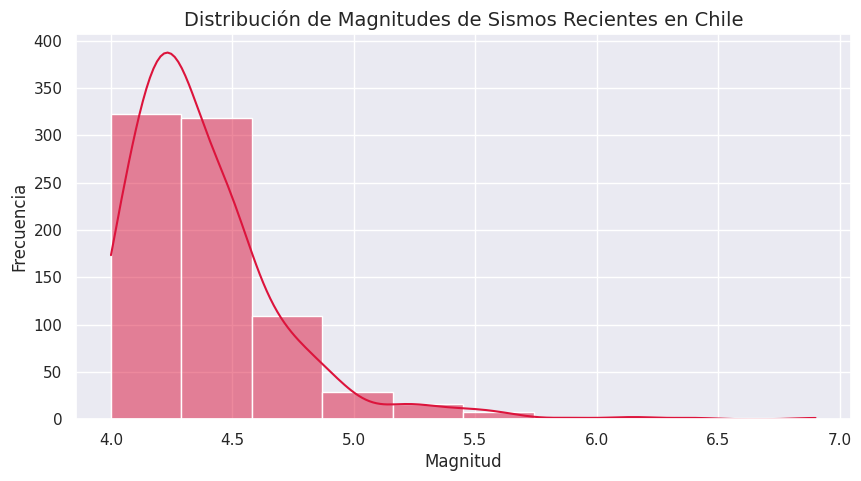

In [8]:
# Gráfico 1: Distribución de Magnitudes
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='magnitude', bins=10, kde=True, color="crimson")
plt.title('Distribución de Magnitudes de Sismos Recientes en Chile', fontsize=14)
plt.xlabel('Magnitud')
plt.ylabel('Frecuencia')
plt.show()

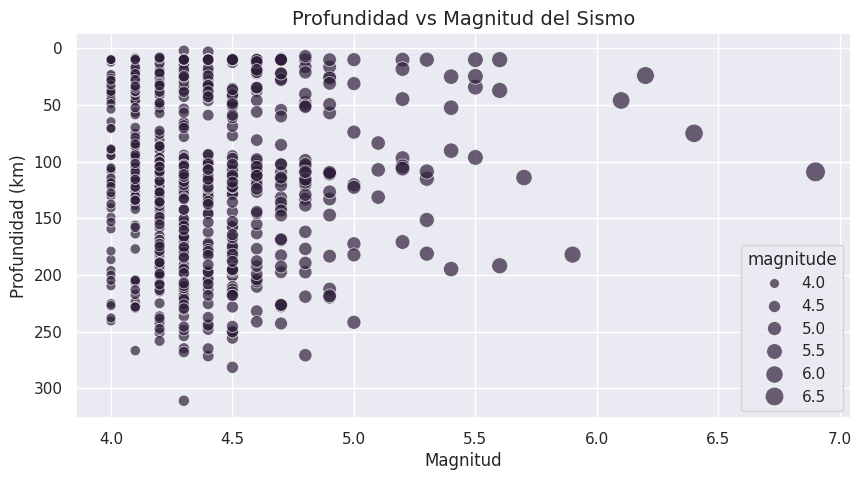

In [9]:
# Gráfico 2: Profundidad vs Magnitud
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='magnitude', y='depth', size='magnitude', sizes=(50, 200), alpha=0.7)
plt.gca().invert_yaxis()  # Invertir eje Y para simular profundidad subterránea
plt.title('Profundidad vs Magnitud del Sismo', fontsize=14)
plt.xlabel('Magnitud')
plt.ylabel('Profundidad (km)')
plt.show()

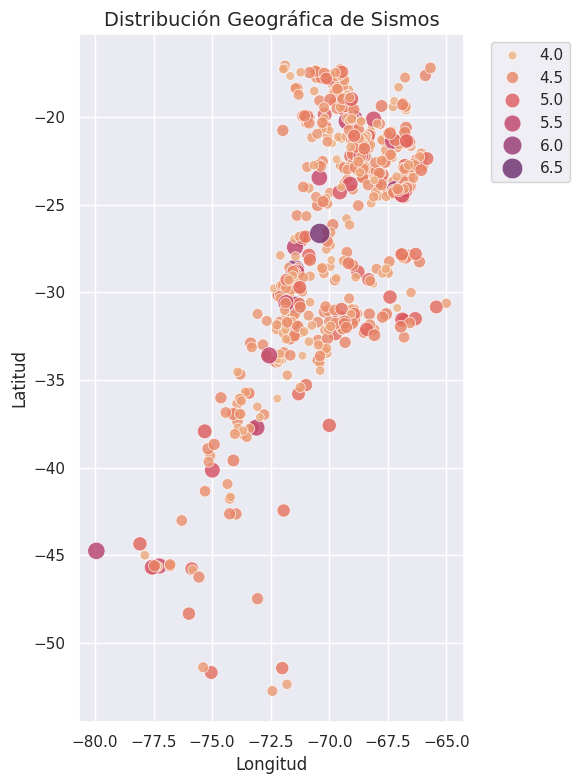

In [10]:
# Gráfico 3: Dispersión Geográfica de los Epicentros
plt.figure(figsize=(6, 8))
sns.scatterplot(data=df, x='longitude', y='latitude', hue='magnitude', size='magnitude', sizes=(40, 250), palette='flare', alpha=0.8)
plt.title('Distribución Geográfica de Sismos', fontsize=14)
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()